In [1]:
import pandas as pd
import numpy as np


In [2]:
np.random.seed(42)
x=np.random.rand(100,1)-0.5
y=3*x[:,0]**2+0.05*np.random.randn(100)

In [3]:
import matplotlib.pyplot as plt

In [5]:
df=pd.DataFrame()
df["x"]=x.reshape(100)
df["y"]=y

In [6]:
df

,x,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


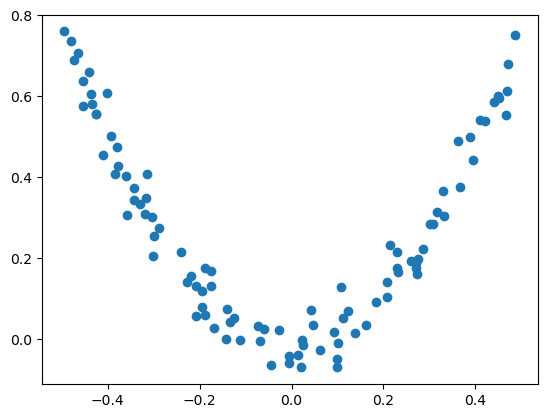

In [7]:
plt.scatter(df['x'],df['y'])


In [8]:
df['pred1']=df['y'].mean()

In [9]:
df

,x,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458
...,...,...,...
95,-0.006204,-0.040675,0.265458
96,0.022733,-0.002305,0.265458
97,-0.072459,0.032809,0.265458
98,-0.474581,0.689516,0.265458


In [10]:
df["res1"]=df['y']-df['pred1']

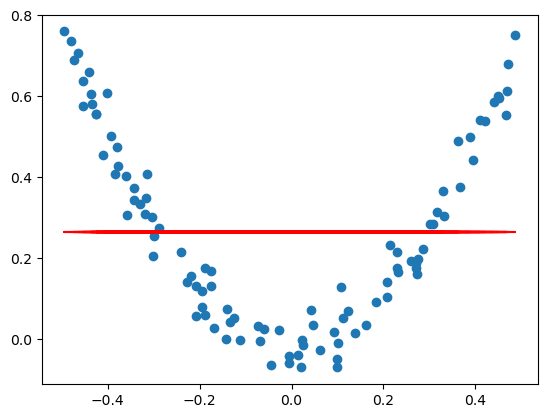

In [12]:
plt.scatter(df["x"],df["y"])
plt.plot(df['x'],df['pred1'],color="red")

In [15]:
from sklearn.tree import DecisionTreeRegressor,plot_tree
tree1=DecisionTreeRegressor(max_depth=8)

In [16]:
tree1.fit(df['x'].values.reshape(100,1),df["res1"].values)

DecisionTreeRegressor(max_depth=8)

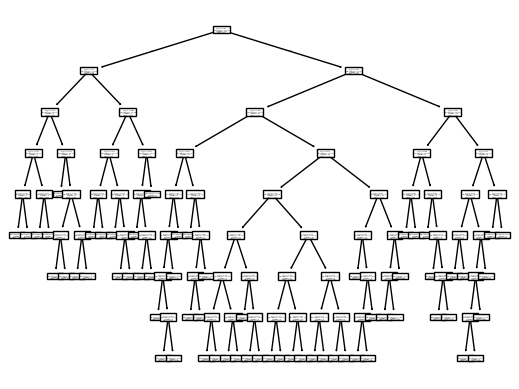

In [18]:
plot_tree(tree1)
plt.show()

In [21]:
x_test=np.linspace(-0.5,0.5,100)

In [22]:
y_pred=0.265458+tree1.predict(x_test.reshape(100,1))    

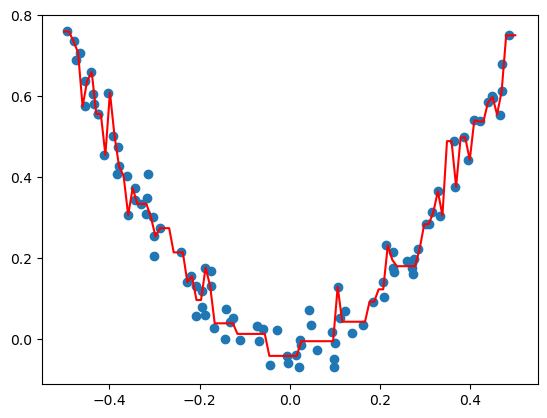

In [25]:
plt.scatter(df["x"],df["y"])
plt.plot(x_test,y_pred,color="red")

In [26]:
df['pred2']=0.265458+tree1.predict(df['x'].values.reshape(100,1))

In [27]:
df["res2"]=df["y"]-df["pred2"]

In [28]:
df

,x,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.038881,1.269182e-02
1,0.450714,0.594480,0.265458,0.329021,0.597626,-3.145898e-03
2,0.231994,0.166052,0.265458,-0.099407,0.179941,-1.388927e-02
3,0.098658,-0.070178,0.265458,-0.335636,-0.005301,-6.487648e-02
4,-0.343981,0.343986,0.265458,0.078528,0.334017,9.969285e-03
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,-0.041576,9.009411e-04
96,0.022733,-0.002305,0.265458,-0.267763,-0.005301,2.996734e-03
97,-0.072459,0.032809,0.265458,-0.232650,0.012734,2.007499e-02
98,-0.474581,0.689516,0.265458,0.424057,0.689515,3.966968e-07


In [29]:
tree2=DecisionTreeRegressor(max_depth=8)
tree2.fit(df['x'].values.reshape(100,1),df["res2"].values)

DecisionTreeRegressor(max_depth=8)

In [30]:
y_pred=0.265458+sum(reggressor.predict(x_test.reshape(100,1)) for reggressor in [tree1,tree2])

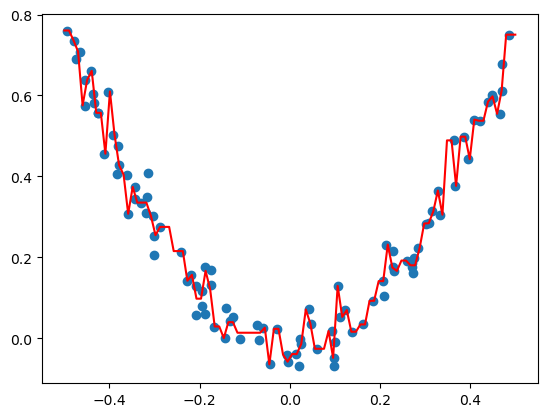

In [31]:
plt.scatter(df["x"],df["y"])
plt.plot(x_test,y_pred,color="red")

## Here we will make a function for gradient boosting

|

In [37]:
def gradient_boosting(x, y, n_estimators, lr=1.0, max_depth=8):
    """Simple gradient boosting implementation using decision trees.

    Plots the prediction after each boosting step.
    """
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y)

    # initial prediction – constant model
    F0 = y.mean()
    y_pred = np.full_like(y, F0, dtype=float)

    regs = []
    for i in range(n_estimators):
        residual = y - y_pred
        tree = DecisionTreeRegressor(max_depth=max_depth)
        tree.fit(x, residual)
        regs.append(tree)

        # update the ensemble prediction
        y_pred += lr * tree.predict(x)

        # show progress on a test grid
        x_test = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
        y_test_pred = F0 + sum(lr * r.predict(x_test) for r in regs)

        plt.figure()
        plt.scatter(x, y, alpha=0.6)
        plt.plot(x_test, y_test_pred, color="red")
        plt.title(f"Boosting iteration {i+1}")
        plt.show()

    return F0, regs


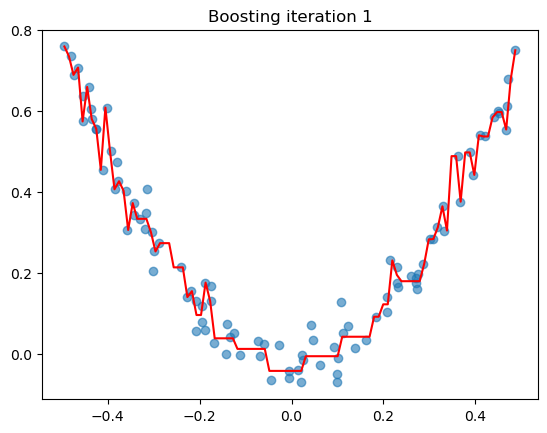

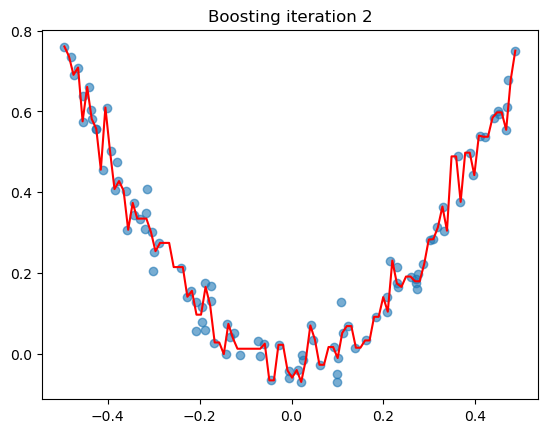

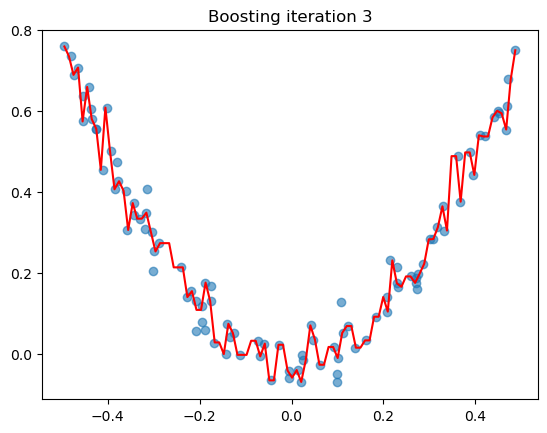

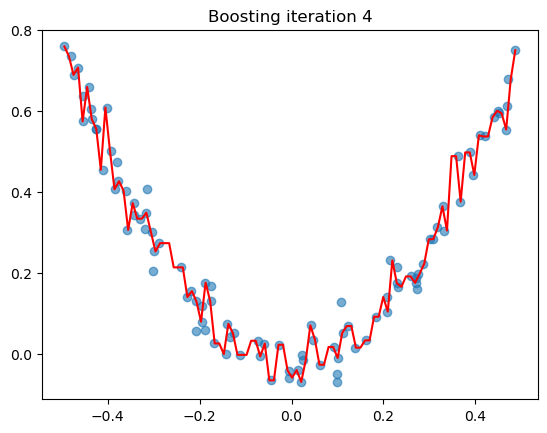

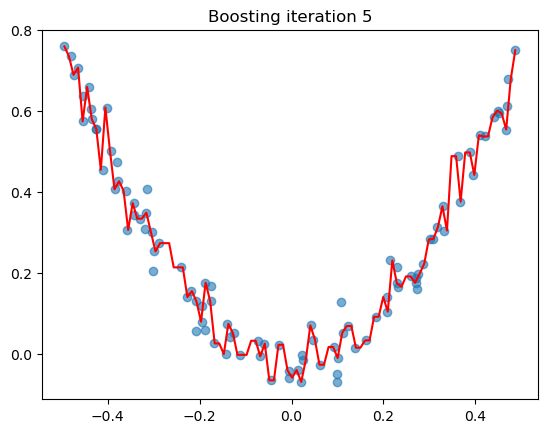

initial constant prediction 0.26545839669679816
number of trees 5


In [38]:
np.random.seed(42)
x = np.random.rand(100,1) - 0.5
# target follows a simple quadratic with noise
y = 3*x[:,0]**2 + 0.05*np.random.randn(100)

# run our corrected booster
F0, regs = gradient_boosting(x, y, n_estimators=5, lr=1.0)

print("initial constant prediction", F0)
print("number of trees", len(regs))